In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:.6f}'.format


In [1]:
filename = "../data/BTCUSDT_hourly.csv"

In [26]:
def view_data(df):
    print(df.head(10))
    
    

In [69]:
def load_data(filename):
    df = pd.read_csv(filename)
    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1)) / np.log(df["Close"])
    # Define labels based on 1-hour interval price movement
    df["label"] = 0  # Default class (no significant movement)
    df.loc[df["log_return"] >= 0.000875, "label"] = 1  # Uptrend
    df.loc[df["log_return"] <= -0.000875, "label"] = -1  # Downtrend
    
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["period"] = df["timestamp"].dt.to_period("M")
    
    df.dropna(inplace=True)
    return df


df = load_data(filename)
df.head()


,timestamp,Open,High,Low,Close,Volume,log_return,label,period
1,2018-01-01 01:00:00,13528.990000,13595.890000,13155.380000,13203.060000,383.697006,-0.002570,-1,2018-01
2,2018-01-01 02:00:00,13203.000000,13418.430000,13200.000000,13330.180000,429.064572,0.001009,1,2018-01
3,2018-01-01 03:00:00,13330.260000,13611.270000,13290.000000,13410.030000,420.087030,0.000628,0,2018-01
4,2018-01-01 04:00:00,13434.980000,13623.290000,13322.150000,13601.010000,340.807329,0.001486,1,2018-01
5,2018-01-01 05:00:00,13615.200000,13699.000000,13526.500000,13558.990000,404.229046,-0.000325,0,2018-01


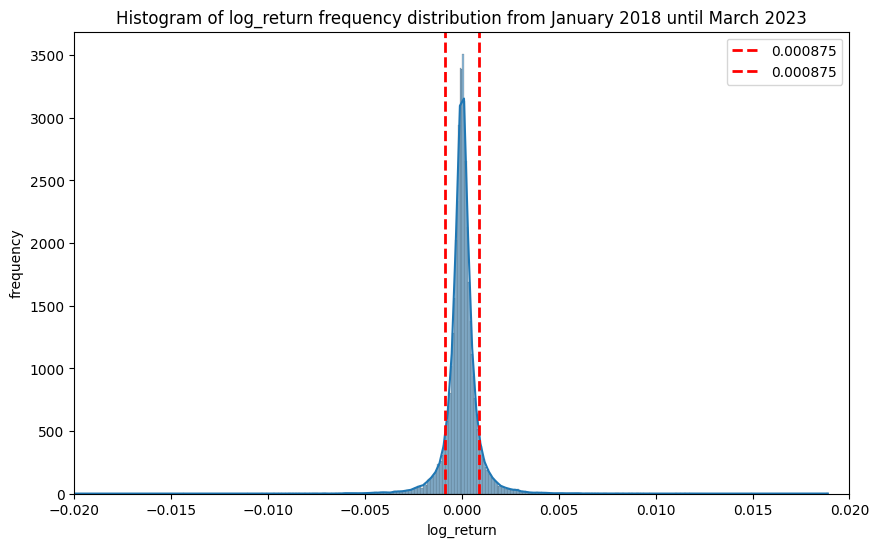

In [70]:
#plot frequency distribution
std_val = round(df["log_return"].std(),6)
plt.figure(figsize=(10, 6))
sns.histplot(df["log_return"], bins=550, kde=True)
plt.xlim([-0.02, 0.02])
plt.axvline(x=std_val, color='red', linestyle='--', linewidth=2, label=str(std_val))
plt.axvline(x=-std_val, color='red', linestyle='--', linewidth=2, label=str(std_val))
plt.xlabel("log_return")
plt.ylabel("frequency")
plt.title("Histogram of log_return frequency distribution from January 2018 until March 2023")
plt.legend()
plt.show()

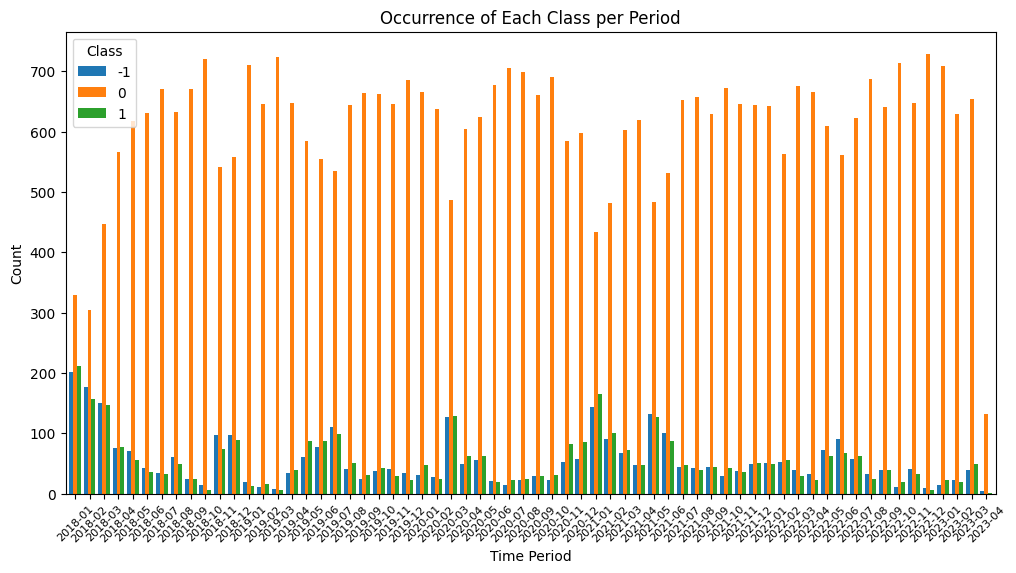

In [71]:
# Count occurrences per class per period
class_counts = df.groupby(["period", "label"]).size().unstack().fillna(0)

# Plot grouped bar chart
class_counts.plot(kind="bar", figsize=(12, 6), width=0.8)
plt.xlabel("Time Period")
plt.ylabel("Count")
plt.title("Occurrence of Each Class per Period")
plt.legend(title="Class")
plt.xticks(rotation=45, fontsize=8)
plt.show()